In [38]:
# Importando bibliotecas

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

In [22]:
# Carregando o arquivo query01.csv

df = pd.read_csv('query01.csv')

display(df.head(50))

,FIRST_NAME,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,JOB_TITLE
0,Jennifer,4400,10.0,Administration,Administration Assistant
1,Michael,13000,20.0,Marketing,Marketing Manager
2,Pat,6000,20.0,Marketing,Marketing Representative
3,Den,11000,30.0,Purchasing,Purchasing Manager
4,Alexander,3100,30.0,Purchasing,Purchasing Clerk
5,Shelli,2900,30.0,Purchasing,Purchasing Clerk
6,Sigal,2800,30.0,Purchasing,Purchasing Clerk
7,Guy,2600,30.0,Purchasing,Purchasing Clerk
8,Karen,2500,30.0,Purchasing,Purchasing Clerk
9,Susan,6500,40.0,Human Resources,Human Resources Representative


In [3]:
# Fazendo uma análise inicial do DataFrame 01

display(f"Número de registros: {df.shape[0]}")
display(f"Número de colunas: {df.shape[1]}")
display(f"Tipos de informação da coluna: {df.dtypes}")
display(f"Valores nulos nas colunas: {df.isnull().sum()}")
display(f"Valores duplicados nas colunas: {df.duplicated().sum()}")

'Número de registros: 107'

'Número de colunas: 5'

'Tipos de informação da coluna: FIRST_NAME             str\nSALARY               int64\nDEPARTMENT_ID      float64\nDEPARTMENT_NAME        str\nJOB_TITLE              str\ndtype: object'

'Valores nulos nas colunas: FIRST_NAME         0\nSALARY             0\nDEPARTMENT_ID      1\nDEPARTMENT_NAME    1\nJOB_TITLE          0\ndtype: int64'

'Valores duplicados nas colunas: 0'

Através da análise inicial, foram encontrados dois valores nulos no dataframe. Oprimeiro na coluna nDEPARTMENT_ID e o segundo na coluna DEPARTMENT_NAME.

In [4]:
# Verificando os valores presentes na coluna DEPARTMENT_NAME

display(f"DEPARTMENT_NAME: {df['DEPARTMENT_NAME'].unique()}")

"DEPARTMENT_NAME: <StringArray>\n[  'Administration',        'Marketing',       'Purchasing',\n  'Human Resources',         'Shipping',               'IT',\n 'Public Relations',            'Sales',        'Executive',\n          'Finance',       'Accounting',                nan]\nLength: 12, dtype: str"

In [8]:
# Verificando os valores presentes na coluna DEPARTMENT_ID

display(f"DEPARTMENT_ID: {df['DEPARTMENT_ID'].unique()}")
display(df[df['DEPARTMENT_ID'].isna()])

'DEPARTMENT_ID: [ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110.  nan]'

,FIRST_NAME,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,JOB_TITLE
106,Kimberely,7000,NaN,NaN,Sales Representative


Após uma análise mais profunda, foi verificado a falta de dados do departamento onde atua a funcionária Kimberly. Sugiro que a equipe de recursos humanos tome as providêcias necessárias para corrigir o erro.

Iniciando análises referentes a salários de colaboradores

In [71]:
# Análise geral dos salários dos colaboradores


salario = df[["SALARY"]]

media = salario["SALARY"].mean()
mediana = salario["SALARY"].median()
desvio_padrao = salario["SALARY"].std()
moda = salario["SALARY"].mode().iloc[0]
maximo = salario["SALARY"].max()
minimo = salario["SALARY"].min()
contagem = salario["SALARY"].count()

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio_padrao:.2f}")
print(f"Moda: {moda}")
print(f"Máximo: {maximo}")
print(f"Mínimo: {minimo}")
print(f"Contagem: {contagem}")

Média: 6461.83
Mediana: 6200.00
Desvio padrão: 3909.58
Moda: 2500
Máximo: 24000
Mínimo: 2100
Contagem: 107



Com base nos dados apresentados, podemos fazer a seguinte análise dos salários de uma maneira geral:

A média salarial é de 6.461,83 (Não foi encontrada informação alguma sobre qual a moeda utilizada para pagamentos), enquanto a mediana é de 6.200,00.

O salário mais frequente (moda) é de 2.500,00, indicando que esse valor aparece mais vezes na base analisada. O menor salário é de 2.100,00, enquanto o maior chega a R$ 24.000,00, mostrando uma amplitude salarial bastante elevada.

Por fim, foram analisados 107 registros. De maneira geral, os dados indicam uma distribuição salarial heterogênea, com concentração de alguns salários em valores mais baixos e uma parcela de salários significativamente maiores, o que contribui para elevar a média e aumentar a dispersão dos dados.

In [ ]:
Colaboradores_salario = (
    df[["SALARY", "DEPARTMENT_NAME", "JOB_TITLE"]].sort_values("DEPARTMENT_NAME"))

media = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].mean()
mediana = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].median()
desvio_padrao = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].std()
moda = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].agg(lambda x: x.mode().iloc[0])
maximo = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].max()
minimo = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].min()
contagem = Colaboradores_salario.groupby("DEPARTMENT_NAME")["SALARY"].count()

print(f"Média:\n{media.round(2)}")
print(f"\nMediana:\n{mediana.round(2)}")
print(f"\nDesvio padrão:\n{desvio_padrao.round(2)}")
print(f"\nModa:\n{moda}")
print(f"\nMáximo:\n{maximo}")
print(f"\nMínimo:\n{minimo}")
print(f"\nContagem:\n{contagem}")

Média:
DEPARTMENT_NAME
Accounting          10154.00
Administration       4400.00
Executive           19333.33
Finance              8601.33
Human Resources      6500.00
IT                   5760.00
Marketing            9500.00
Public Relations    10000.00
Purchasing           4150.00
Sales                8955.88
Shipping             3475.56
Name: SALARY, dtype: float64

Mediana:
DEPARTMENT_NAME
Accounting          10154.0
Administration       4400.0
Executive           17000.0
Finance              8000.0
Human Resources      6500.0
IT                   4800.0
Marketing            9500.0
Public Relations    10000.0
Purchasing           2850.0
Sales                8900.0
Shipping             3100.0
Name: SALARY, dtype: float64

Desvio padrão:
DEPARTMENT_NAME
Accounting          2621.95
Administration          NaN
Executive           4041.45
Finance             1804.13
Human Resources         NaN
IT                  1925.62
Marketing           4949.75
Public Relations        NaN
Purchasing

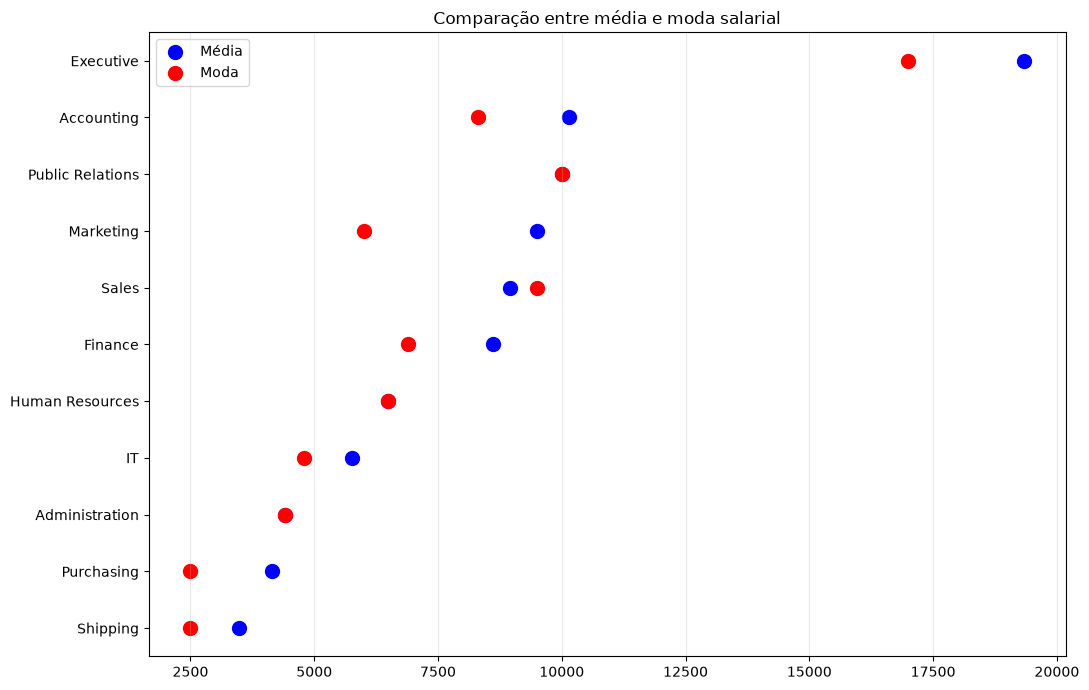

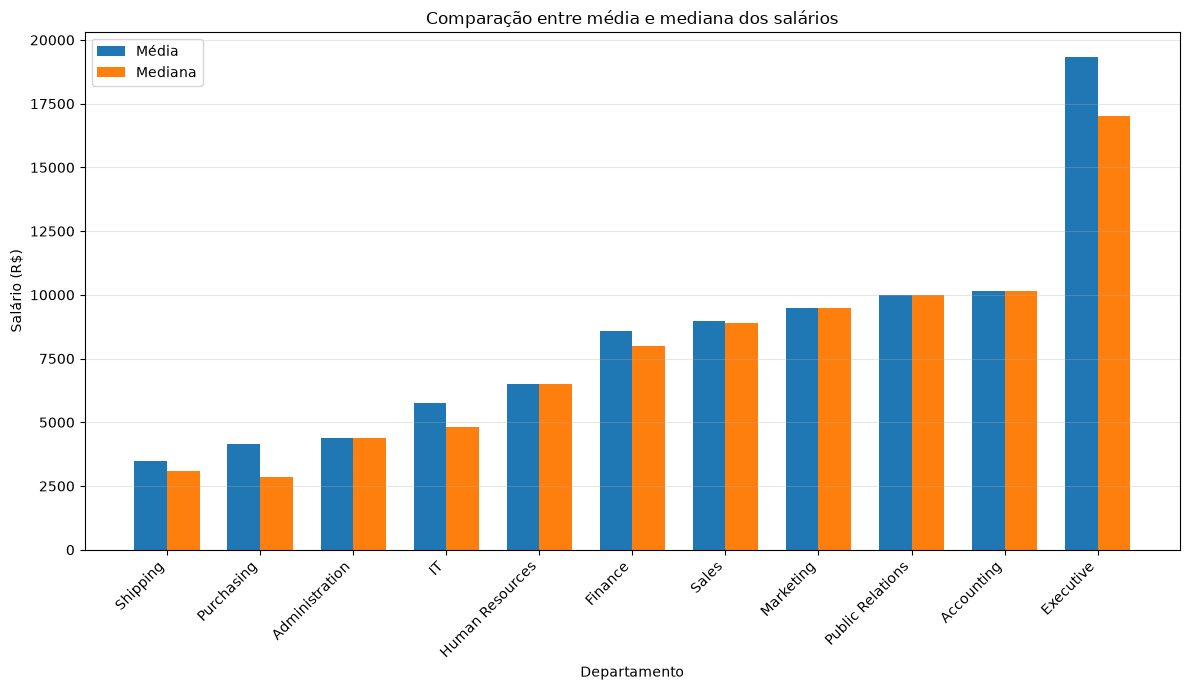

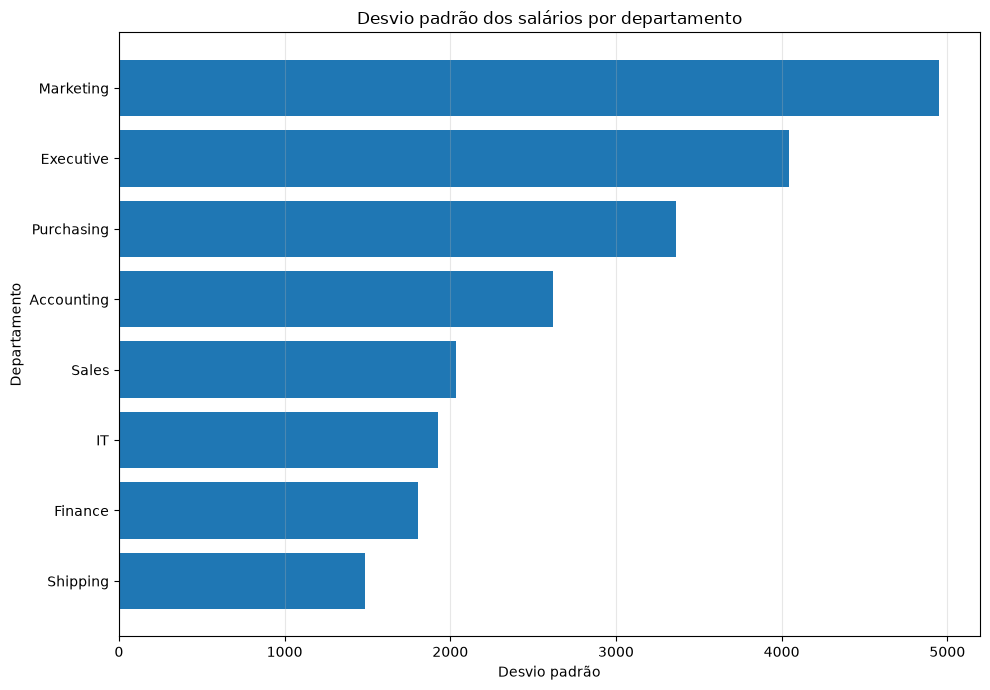

In [ ]:
# Média salarial e Moda por departamento

Colaboradores = (
    df[["SALARY", "DEPARTMENT_NAME"]].sort_values("DEPARTMENT_NAME"))

estatisticas = (
    Colaboradores.groupby("DEPARTMENT_NAME")["SALARY"].agg(
        media="mean",
        moda=lambda x: x.mode().iloc[0]
    ).sort_values("media")
)

plt.figure(figsize=(11, 7))

plt.scatter(
    estatisticas["media"],
    estatisticas.index,
    s=100,
    color="blue",
    label="Média"
)

plt.scatter(
    estatisticas["moda"],
    estatisticas.index,
    s=100,
    color="red",
    label="Moda"
)

plt.title("Comparação entre média e moda salarial")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#Comparação entre média e mediana dos salários por departamento

estatisticas = (
    Colaboradores.groupby("DEPARTMENT_NAME")["SALARY"].agg(["mean", "median"]).sort_values("mean")
)

departamentos = estatisticas.index
medias = estatisticas["mean"]
medianas = estatisticas["median"]

x = np.arange(len(departamentos))
largura = 0.35

plt.figure(figsize=(12, 7))

plt.bar(
    x - largura / 2,
    medias,
    largura,
    label="Média"
)

plt.bar(
    x + largura / 2,
    medianas,
    largura,
    label="Mediana"
)

plt.xticks(
    x,
    departamentos,
    rotation=45,
    ha="right"
)


#Desvio padrão dos salários por departamento
plt.title("Comparação entre média e mediana dos salários")
plt.xlabel("Departamento")
plt.ylabel("Salário (R$)")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

desvio_departamento = (
    Colaboradores
    .groupby("DEPARTMENT_NAME")["SALARY"]
    .std()
    .sort_values()
)

plt.figure(figsize=(10, 7))

plt.barh(
    desvio_departamento.index,
    desvio_departamento.values
)

plt.title("Desvio padrão dos salários por departamento")
plt.xlabel("Desvio padrão")
plt.ylabel("Departamento")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Com base nos dados apresentados, podemos observar diferenças significativas na distribuição dos salarios entre os departamentos.

A maior média salarial está no departamento de Executive, com 19.333,33, seguido por Accounting, com 10.154,00, e Public Relations, com 10.000,00. Já os departamentos com menores médias são Administration, com 4.400,00, Purchasing, com 4.150,00, e Shipping, com 3.475,56.

A comparação entre média e mediana mostra algumas diferenças interessantes. Em Executive, por exemplo, a média é de 19.333,33 e a mediana é 17.000,00, indicando a presença de um salário mais elevado, que contribui para elevar a média. Em IT, a média de 5.760,00 também está acima da mediana de 4.800,00, enquanto em Purchasing a diferença é ainda maior: média de 4.150,00 contra mediana de 2.850,00.

O desvio padrão também evidencia diferenças na dispersão dos salários. Marketing apresenta um desvio padrão de 4.949,75, indicando uma grande variação salarial dentro do departamento. Executive, com 4.041,45, e Accounting, com 2.621,95, também apresentam dispersão relevante. Em contrapartida, Shipping possui desvio padrão de 1.488,01, indicando uma distribuição relativamente mais concentrada. Departamentos como Administration, Human Resources e Public Relations possuem apenas um registro cada, portanto não há como calcular seus desvios.

A moda mostra os salários que aparecem com maior frequência em cada departamento. Em Accounting, a moda é 8.300, enquanto em Executive é 17.000. Já em Purchasing e Shipping, a moda é de 2.500,00, indicando maior frequência desse salário nesses departamentos.

Por fim, a quantidade de registros varia bastante entre os departamentos. Shipping possui 45 registros e Sales 34, concentrando a maior parte das observações. Em contrapartida, departamentos como Administration, Human Resources e Public Relations possuem apenas um registro cada. Isso explica os valores NaN no desvio padrão desses departamentos.

Em resumo: os dados mostram uma forte diferença salarial entre os departamentos, com Executive apresentando os maiores valores e Shipping concentrando salários mais baixos. A quantidade desigual de registros também é um fator importante na interpretação dos resultados, especialmente nos departamentos com poucas observações.